# 11 · SAR

Notebook de análisis para el modelo autorregresivo espacial implementado en `SpatialAutoregressiveModel`.

## Hipótesis del modelo

- Parte del precio se explica por la dependencia espacial entre propiedades cercanas.
- El parámetro espacial `rho` debería capturar interacción espacial no absorbida por las covariables.
- La interpretación principal del modelo surge de los coeficientes globales, `rho` y los patrones de residuos.

In [26]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import geopandas as gpd
import seaborn as sns


PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from ml_core.models.sarModel import SpatialAutoregressiveModel
from ml_core.evaluation.modelEvaluator import regression_metrics
from ml_core.visualization.mapper import *
from ml_core import load_model_config, save_model_config

OUTPUT_DIR = PROJECT_ROOT / "notebooks" / "output" / "11_sar"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid")


## Datos y split

In [27]:
DATA_PATH = PROJECT_ROOT / "data" / "splits"

subset_config = {
    "train_n": 2500,
    "val_n": 800,
    "test_n": 800,
    "random_state": 42,
}


def subset_split(gdf, n_rows, random_state):
    if n_rows is None or len(gdf) <= n_rows:
        return gdf.copy().reset_index(drop=True)
    return (
        gdf.sample(n=n_rows, random_state=random_state)
        .sort_index()
        .reset_index(drop=True)
    )


train_raw = pd.read_csv(DATA_PATH / "arg_venta_data_train.csv")
gdf_train_full = gpd.GeoDataFrame(
    train_raw,
    geometry=gpd.points_from_xy(
        train_raw["longitud"],
        train_raw["latitud"]
    ),
    crs="EPSG:4326"
)

test_raw = pd.read_csv(DATA_PATH / "arg_venta_data_test.csv")
gdf_test_full = gpd.GeoDataFrame(
    test_raw,
    geometry=gpd.points_from_xy(
        test_raw["longitud"],
        test_raw["latitud"]
    ),
    crs="EPSG:4326"
)

val_raw = pd.read_csv(DATA_PATH / "arg_venta_data_val.csv")
gdf_val_full = gpd.GeoDataFrame(
    val_raw,
    geometry=gpd.points_from_xy(
        val_raw["longitud"],
        val_raw["latitud"]
    ),
    crs="EPSG:4326"
)

gdf_train = subset_split(gdf_train_full, subset_config["train_n"], subset_config["random_state"])
gdf_val = subset_split(gdf_val_full, subset_config["val_n"], subset_config["random_state"] + 1)
gdf_test = subset_split(gdf_test_full, subset_config["test_n"], subset_config["random_state"] + 2)

target_col = "log_precio"
coord_cols = ["longitud", "latitud"]
feature_cols = [
    'area_m2_cubierta',
    'area_m2_descubierta',
    'ambientes',
    'antiguedad',
    'expensas',
    'banos',
    'cocheras',
    'estado_num',
    'disposicion_Frente',
    'disposicion_Contrafrente',
    'disposicion_Lateral',
    'dist_subte',
    'dist_universidad',
    'dist_hospital',
    'dist_est_educativo',
    'dist_espacio_verde',
    'dist_areas_programaticas',
    'dist_avenida_rivadavia',
    "n_robos_1000m",
    "n_universidades_1000m",
    "pozo",
    "velocidad_ventas_1000m_90d"
]
print(
    f"Subset SAR -> train={len(gdf_train)} / val={len(gdf_val)} / test={len(gdf_test)}"
)


Subset SAR -> train=2500 / val=800 / test=800


In [28]:
X_train = gdf_train[feature_cols]
y_train = gdf_train[target_col]
coords_train = gdf_train[coord_cols].to_numpy()

X_test = gdf_test[feature_cols]
y_test = gdf_test[target_col]
coords_test = gdf_test[coord_cols].to_numpy()

X_val = gdf_val[feature_cols]
y_val = gdf_val[target_col]
coords_val = gdf_val[coord_cols].to_numpy()


## Tuning de hiperparámetros

Buscamos la mejor combinación de `k` y `radius_km` usando el split de validación. Si ya existe una cache con esta búsqueda, se reutiliza; si querés forzar el recálculo, cambiá `force_recompute_tuning = True`.

In [29]:
config_path = PROJECT_ROOT / "notebooks" / "cache" / "sar_best_config.json"
sar_config = {
    "k": 5,
    "radius_km": 3.0,
}

sar_config

tuning_search_space = {
    "k": [3, 5, 8, 10, 15, 20],
    "radius_km": [1.0, 2.0, 3.0, 5.0],
}
force_recompute_tuning = False

saved_config = None if force_recompute_tuning else load_model_config(config_path)

if saved_config is None or "tuning_results" not in saved_config:
    tuning_rows = []

    for radius_km in tuning_search_space["radius_km"]:
        for k in tuning_search_space["k"]:
            candidate_config = sar_config.copy()
            candidate_config["k"] = int(k)
            candidate_config["radius_km"] = float(radius_km)

            candidate = SpatialAutoregressiveModel(sar_config=candidate_config)

            try:
                candidate.fit(X_train, y_train, coords_train)
                y_val_pred_log = candidate.predict(X_val, coords_val)
                y_val_pred = np.exp(np.asarray(y_val_pred_log).reshape(-1))
                y_val_true = np.exp(np.asarray(y_val).reshape(-1))
                candidate_metrics = regression_metrics(y_val_true, y_val_pred)

                tuning_rows.append({
                    "k": int(k),
                    "radius_km": float(radius_km),
                    "rmse": candidate_metrics["rmse"],
                    "mae": candidate_metrics["mae"],
                    "r2": candidate_metrics["r2"],
                    "mape": candidate_metrics["mape"],
                    "status": "ok",
                })
            except Exception as exc:
                tuning_rows.append({
                    "k": int(k),
                    "radius_km": float(radius_km),
                    "rmse": None,
                    "mae": None,
                    "r2": None,
                    "mape": None,
                    "status": f"error: {exc}",
                })

    tuning_results = (
        pd.DataFrame(tuning_rows)
        .sort_values(["rmse", "mae"], na_position="last")
        .reset_index(drop=True)
    )

    successful_results = (
        tuning_results[tuning_results["status"] == "ok"]
        .reset_index(drop=True)
    )

    if successful_results.empty:
        raise ValueError("No se encontró ninguna configuración válida para SAR.")

    best_row = successful_results.iloc[0]
    sar_config = {
        **sar_config,
        "k": int(best_row["k"]),
        "radius_km": float(best_row["radius_km"]),
    }
    selected_k = int(best_row["k"])

    tuning_model = SpatialAutoregressiveModel(sar_config=sar_config.copy())
    tuning_model.k = selected_k
    tuning_model.k_ = selected_k
    tuning_model.best_params_ = {
        "k": selected_k,
        "radius_km": float(best_row["radius_km"]),
    }

    save_model_config(
        tuning_model,
        config_path,
        extra={
            "target": target_col,
            "features": feature_cols,
            "subset_config": subset_config,
            "search_space": tuning_search_space,
            "selection_metric": "rmse",
            "tuning_results": successful_results.to_dict(orient="records"),
        },
    )

    saved_config = load_model_config(config_path)

tuning_results = pd.DataFrame(saved_config.get("tuning_results", []))
sar_config = saved_config.get("sar_params", sar_config)
selected_k = saved_config.get("selected_k", sar_config.get("k"))

best_config = {
    "sar_params": sar_config,
    "selected_k": selected_k,
    "search_space": saved_config.get("search_space", tuning_search_space),
    "selection_metric": saved_config.get("selection_metric", "rmse"),
}

display(tuning_results.head(10))
best_config


,k,radius_km,rmse,mae,r2,mape,status
0,5,3.0,61210.914248,36008.959353,0.781482,22.805138,ok
1,5,2.0,61423.125221,36104.559626,0.779964,22.790593,ok
2,8,2.0,61529.117560,36284.039369,0.779204,22.909265,ok
3,8,3.0,61551.625486,36353.675375,0.779042,23.025143,ok
4,8,5.0,61553.443453,36251.511708,0.779029,23.128523,ok
5,5,5.0,61700.237304,36350.272185,0.777974,23.010369,ok
6,10,2.0,62017.105173,36533.205854,0.775688,23.068685,ok
7,10,5.0,62154.938614,36499.539399,0.774690,23.193083,ok
8,5,1.0,62173.033854,35889.761216,0.774559,22.727263,ok
9,15,2.0,62228.089256,36351.821549,0.774159,23.047919,ok


{'sar_params': {'k': 5, 'radius_km': 3.0},
 'selected_k': 5,
 'search_space': {'k': [3, 5, 8, 10, 15, 20],
  'radius_km': [1.0, 2.0, 3.0, 5.0]},
 'selection_metric': 'rmse'}

## Evaluación global

In [30]:
sar_config = best_config["sar_params"]
selected_k = best_config["selected_k"]

model = SpatialAutoregressiveModel(sar_config=sar_config.copy())
if selected_k is not None:
    model.k = int(selected_k)
    model.sar_params["k"] = int(selected_k)

model.fit(X_train, y_train, coords_train)
model

y_pred_log = model.predict(
    X_val,
    coords_val
)

# Deshacer la transformación logarítmica
y_pred = np.exp(np.asarray(y_pred_log).reshape(-1))
y_true = np.exp(np.asarray(y_val).reshape(-1))

metrics = regression_metrics(
    y_true,
    y_pred
)

metrics


/home/saneliges/Escritorio/PredictorPrecioMetroCuadradoAlquileres/ml_core/models/sarModel.py:105: UserWarning: The weights matrix is not fully connected: 
 There are 3 disconnected components.
  w = W(neighbors, weights)


ML_Lag


{'rmse': 61210.91424752732,
 'mae': 36008.95935265273,
 'r2': 0.7814818892672883,
 'bias': 8103.807716507091,
 'median_abs_error': 20974.007220853724,
 'mape': 22.805137538066457}

## Visualización

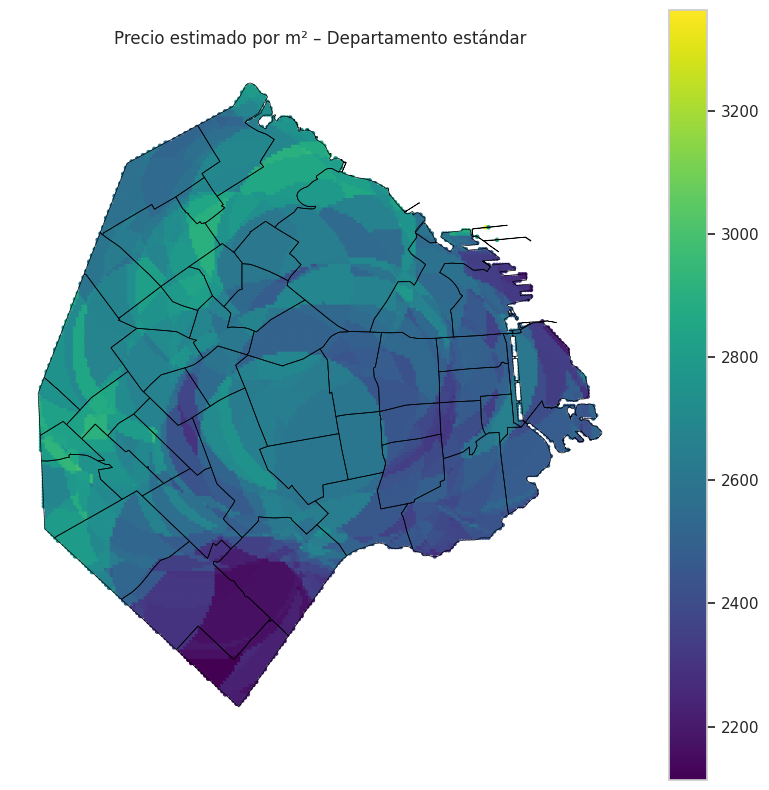

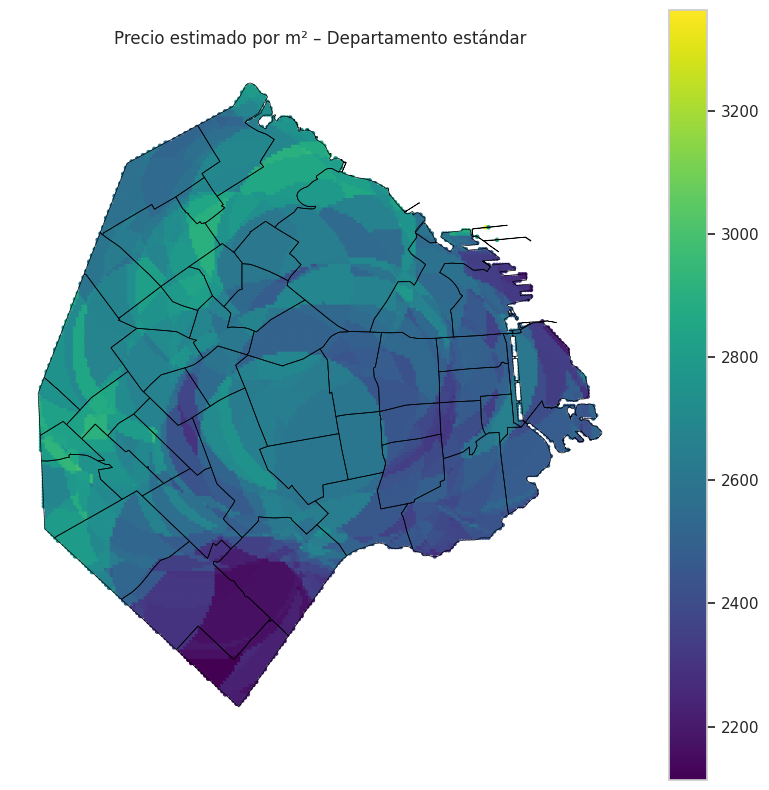

In [31]:
barrios_path = PROJECT_ROOT / 'GeoData' / 'barrios.geojson'

df_grid, barrios, std = generar_grid_predicciones(
    model,
    gdf_val,
    feature_cols
)

mapa = MapaPrecio(df_grid, barrios)

mapa.plot()

# mapa.save("mapa_modelo_sar.png")

# mapa.save("mapa_modelo_sar.pdf")



## Interpretación de resultados

A continuación mostramos el parámetro de autocorrelación espacial estimado por el modelo SAR y un resumen de la matriz de pesos construida sobre el conjunto de entrenamiento.

En la siguiente celda observamos que `rho` es positivo. Esto indica que el modelo detecta una asociación espacial positiva entre propiedades vecinas: manteniendo constantes las covariables, precios altos tienden a estar rodeados por precios altos, y precios bajos por precios bajos. En este notebook sólo mostramos el valor estimado de `rho`, por lo que no corresponde afirmar significancia estadística sin consultar el resumen completo del modelo.
Además, la mejor configuración encontrada fue `k = 5` y `radius_km = 3.0`. Esto sugiere que, para este subconjunto de datos, el modelo obtiene mejor desempeño cuando cada propiedad se vincula con un conjunto acotado de vecinos candidatos dentro de un radio de 3 km.
Vale recordar que la selección final de vecinos no depende únicamente de la distancia geográfica en kilómetros: primero se filtran propiedades dentro del radio y luego se priorizan aquellas con features más similares.

In [34]:
rho_value = float(np.asarray(model.model_.rho).reshape(-1)[0])

rho_frame = pd.DataFrame([
    {
        "rho": rho_value,
        "abs_rho": abs(rho_value),
        "signo": "positivo" if rho_value > 0 else "negativo" if rho_value < 0 else "nulo",
        "k": int(model.sar_params.get("k", model.k)),
        "radius_km": float(model.sar_params.get("radius_km", np.nan)),
        "transformacion_pesos": model.w.transform,
    }
])

rho_frame

,rho,abs_rho,signo,k,radius_km,transformacion_pesos
0,0.290216,0.290216,positivo,5,3.0,R


Al analizar el grafo de vecindad, observamos que la densidad espacial no es homogénea en toda CABA: dentro de un radio de 3 km, algunas observaciones quedan conectadas con 5 vecinos y otras con hasta 14.
Esta diferencia afecta directamente los pesos asignados a cada vecino, ya que la matriz se normaliza por fila y los pesos de cada observación deben sumar 1. Por eso, cuando una propiedad tiene 5 vecinos, cada uno recibe un peso de `0.2`; cuando tiene 14, cada peso baja aproximadamente a `0.0714`.

In [35]:
cardinalities = np.asarray(list(model.w.cardinalities.values()), dtype=float)
weight_values = np.concatenate([
    np.asarray(row_weights, dtype=float)
    for row_weights in model.w.weights.values()
    if len(row_weights) > 0
])

weights_summary = pd.DataFrame([
    {
        "n_observaciones": int(model.w.n),
        "n_islas": int(len(model.w.islands)),
        "vecinos_promedio": float(cardinalities.mean()),
        "vecinos_min": int(cardinalities.min()),
        "vecinos_max": int(cardinalities.max()),
        "peso_promedio": float(weight_values.mean()),
        "peso_min": float(weight_values.min()),
        "peso_max": float(weight_values.max()),
    }
])

weights_summary

,n_observaciones,n_islas,vecinos_promedio,vecinos_min,vecinos_max,peso_promedio,peso_min,peso_max
0,2500,0,6.3904,5,14,0.156485,0.071429,0.2
